In [1]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import xgboost

from sklearn import metrics
from sklearn.model_selection import train_test_split

## Data

##### First, get the .csv file containing the titanic data from https://calmcode.io/static/data/titanic.csv

In [2]:
df = pd.read_csv('https://calmcode.io/static/data/titanic.csv')
df = df[["pclass","sex","age","survived"]]
df.dropna(inplace=True)

features = df.columns

# Column sex is type string. Encode it to numerical
mapping = {"female": 0, "male": 1}
df["sex"] = df["sex"].map(mapping)

# Train test split
X_data = df[['pclass', 'sex', 'age']].values
y_data = df['survived'].values
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3)

## Model

In [3]:
def accuracy(true_values, predictions):
    return np.mean(true_values == predictions)

Accuracy:  0.7674418604651163
Precision:  0.8260869565217391
Sensitivity / recall:  0.6


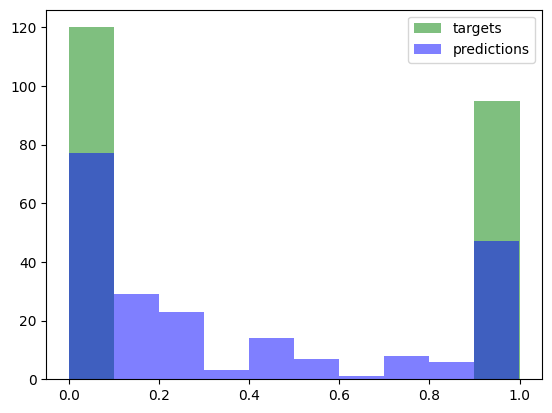

In [4]:
model = xgboost.XGBClassifier()
model.fit(X_train, y_train)

# Predict and evaluate model 
predictions = model.predict(X_test)
print("Accuracy: ", accuracy(y_test, predictions))
print("Precision: ", metrics.precision_score(y_test, predictions))
print("Sensitivity / recall: ", metrics.recall_score(y_test, predictions))

probs  = model.predict_proba(X_test)[:,1]

plt.hist(y_test, color="green", alpha=0.5, label="targets")
plt.hist(probs, color="blue", alpha=0.5, label="predictions")
plt.legend()
plt.show()

In [5]:
def niceprint(l):
    gender = "male" if l[1] == 1 else "female"
    print("Pclass\t|     Gender\t|\tAge\t|")
    print(f"{l[0]} \t|     {gender}\t|\t{l[2]}\t|")

In [6]:
X_paul = [2, 1, 25]
pred_paul = model.predict_proba([X_paul])
print("Paul:")
niceprint(X_paul)
print(f"Chance for survival: {pred_paul[0][1]}\n")

Paul:
Pclass	|     Gender	|	Age	|
2 	|     male	|	25	|
Chance for survival: 0.03414449840784073



In [7]:
print("Chance for survival of counterfactual Paul with")
for cf in [[1,1,25], [2,0,25], [2,1,12]]: 
    niceprint(cf)
    print("is:", model.predict_proba([cf])[0][1])

Chance for survival of counterfactual Paul with
Pclass	|     Gender	|	Age	|
1 	|     male	|	25	|
is: 0.74865675
Pclass	|     Gender	|	Age	|
2 	|     female	|	25	|
is: 0.4096827
Pclass	|     Gender	|	Age	|
2 	|     male	|	12	|
is: 0.88480294


In [8]:
# L1-distance
def distance(x, x_cf):
    return np.sum(np.abs(np.array(x) - np.array(x_cf)))

In [9]:
def counterfactual_loss(model, x, x_cf, y_target, lambda_):
    pred_cf = model.predict_proba([x_cf])[0][1]
    response_proximity = (pred_cf - y_target) ** 2
    feature_proximity = distance(x, x_cf)
    return lambda_ * response_proximity + feature_proximity

In [10]:
def find_counterfactual(
    model,
    x,
    y_target=1.0,
    lam=10.0,
    n_iter=1000,
    step_age=2
):
    best_x_cf = x.copy()
    best_loss = counterfactual_loss(model, x, x, y_target, lam)

    for _ in range(n_iter):

        x_cf = x.copy()

        # Change pclass (1,2,3)
        if random.random() < 0.3:
            x_cf[0] = random.choice([1, 2, 3])

        # Change sex (0=female, 1=male)
        if random.random() < 0.3:
            x_cf[1] = 1 - x_cf[1]

        # Change age slightly
        if random.random() < 0.5:
            x_cf[2] = max(0, x_cf[2] + random.randint(-step_age, step_age))

        loss = counterfactual_loss(model, x, x_cf, y_target, lam)

        if loss < best_loss:
            best_loss = loss
            best_x_cf = x_cf

    return best_x_cf


In [11]:
X_paul = [2, 1, 25]

In [13]:
cf_paul = find_counterfactual(
    model,
    X_paul,
    y_target=1.0,
    lam=15.0
)

In [14]:
print("Original Paul:")
niceprint(X_paul)
print("Survival probability:", model.predict_proba([X_paul])[0][1])

print("\nCounterfactual Paul:")
niceprint(cf_paul)
print("Survival probability:", model.predict_proba([cf_paul])[0][1])

Original Paul:
Pclass	|     Gender	|	Age	|
2 	|     male	|	25	|
Survival probability: 0.0341445

Counterfactual Paul:
Pclass	|     Gender	|	Age	|
1 	|     male	|	25	|
Survival probability: 0.74865675
